In [3]:
from Objects.Transformations import *
from Objects.WSBM import *
from Objects.TWSBMInstance import *

from Computation.Computation import *
from Computation.ExtraMetrics import *

from Plotting.Plotting import *
from Plotting.ArtisticPlotting import *

In [ ]:
def sample_in_rectangle(x_a=0, x_b=1, y_a=0, y_b=1, props=None, traversal='row-major', remove_black=False):
	props = np.asarray(props if props is not None else [0.1, 0.5, 0.9])
	N = props.size
	xs = x_a + props * (x_b - x_a)
	ys = y_a + props * (y_b - y_a)
	xx, yy = np.meshgrid(xs, ys, indexing='xy')
	ii, jj = np.meshgrid(np.arange(N), np.arange(N), indexing='xy')
	order = 'C' if traversal == 'row-major' else 'F'
	flat_x = xx.ravel(order=order)
	flat_y = yy.ravel(order=order)
	flat_i = ii.ravel(order=order)
	flat_j = jj.ravel(order=order)
	if remove_black and N >= 3:
		mask = ((flat_i + flat_j) % 2 == 0)
		flat_x = flat_x[mask]
		flat_y = flat_y[mask]
	return list(zip(flat_x, flat_y))

def plot_embeddings_grid(model, transforms, subfolder, 
						 rhos = RHOS, pis = PIS, model_params = sample_in_rectangle(), q_outliers = 0):
	emb_mode, p22 = EMB_MODES[0], P22S[0]
	metrics = {}
	for rho, pi in product(rhos, pis):
		metrics[(rho, pi)] = {}
		for p11, p12 in model_params:
			m = model(rho, pi, (p11, p12), p22 = p22)
			A, Z = m(42)
			metrics[(rho, pi)][m] = {}
			for t in transforms:
				#print(f"Simulating for rho={rho}, pi={pi}, model={model.name}, transformation={t.id}")
				metrics[(rho, pi)][m][t] = TWSBMInstance(model = m, transformation = t, A = t(A), Z = Z, emb_mode = emb_mode)
	plotter = Plotter(folder_path=emb_mode_p22_path_str(emb_mode, p22))
	for rho, pi in product(rhos, pis):
		plotter.plot_embedding(rho, pi, metrics[(rho, pi)], subfolder = subfolder, q_outliers = q_outliers)

In [ ]:
rects = [sample_in_rectangle(), sample_in_rectangle(remove_black=True)]
transforms_lists_dic = dict(zip(
	['Transforms', 'Powers', 'Quantiles'],
	[TRANSFORMS, TRANSFORMS_POW, TRANSFORMS_QTL]
))

for model in MODELS:
	for ts_name, transforms in transforms_lists_dic.items():
		for rect in rects:
			plot_embeddings_grid(model, transforms, f'{len(rect)}{model.name}/{ts_name}', model_params = rect)

c:\Users\Nicol\Documents\EPFL\MA6\Project\Code\Plotting\Plotting.py:134: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string " " (-> linestyle=' '). The keyword argument will take precedence.
  ax.plot([], [], ' ', label=stat, linestyle = None, marker = "")
c:\Users\Nicol\Documents\EPFL\MA6\Project\Code\Plotting\Plotting.py:134: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string " " (-> linestyle=' '). The keyword argument will take precedence.
  ax.plot([], [], ' ', label=stat, linestyle = None, marker = "")
c:\Users\Nicol\Documents\EPFL\MA6\Project\Code\Plotting\Plotting.py:134: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string " " (-> linestyle=' '). The keyword argument will take precedence.
  ax.plot([], [], ' ', label=stat, linestyle = None, marker = "")
c:\Users\Nicol\Documents\EPFL\MA6\Project\Code\Plotting\Plotting.py:134: UserWa

In [ ]:
transforms = TRANSFORMS_QTL.copy() + [LogTransform()]
subfolder = 'C_true_Regret'

model = betaWSBM
plot_embeddings_grid(model, transforms, f'{subfolder}/{model.name}', 
					 model_params = sample_in_rectangle(0, 0.2, 0.6, 1), 
					 rhos = [0.25], pis = [0.1], q_outliers = 0.01)
plot_embeddings_grid(model, transforms, f'{subfolder}/{model.name}', 
					 model_params = sample_in_rectangle(0.4, 0.65, 0.6, 1), 
					 rhos = [0.5], pis = [0.5], q_outliers = 0.01)

""""
model = lognormWSBM
plot_embeddings_grid(model, transforms, f'{subfolder}/{model.name}', 
					 model_params = sample_in_rectangle(0, 1, 0.3, 0.4), 
					 rhos = [0.1], pis = [0.1], q_outliers = 0.01)
plot_embeddings_grid(model, transforms, f'{subfolder}/{model.name}', 
					 model_params = sample_in_rectangle(0, 0.25, 0.55, 0.65), 
					 rhos = [0.25], pis = [0.25], q_outliers = 0.01)
plot_embeddings_grid(model, transforms, f'{subfolder}/{model.name}', 
					 model_params = sample_in_rectangle(0.4, 0.5, 0.8, 1), 
					 rhos = [0.5], pis = [0.25], q_outliers = 0.01)"""

c:\Users\Nicol\Documents\EPFL\MA6\Project\Code\Plotting\Plotting.py:134: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string " " (-> linestyle=' '). The keyword argument will take precedence.
  ax.plot([], [], ' ', label=stat, linestyle = None, marker = "")
c:\Users\Nicol\Documents\EPFL\MA6\Project\Code\Plotting\Plotting.py:134: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string " " (-> linestyle=' '). The keyword argument will take precedence.
  ax.plot([], [], ' ', label=stat, linestyle = None, marker = "")


'"\nmodel = lognormWSBM\nplot_embeddings_grid(model, transforms, f\'{subfolder}/{model.name}\', \n\t\t\t\t\t model_params = sample_in_rectangle(0, 1, 0.3, 0.4), \n\t\t\t\t\t rhos = [0.1], pis = [0.1], q_outliers = 0.01)\nplot_embeddings_grid(model, transforms, f\'{subfolder}/{model.name}\', \n\t\t\t\t\t model_params = sample_in_rectangle(0, 0.25, 0.55, 0.65), \n\t\t\t\t\t rhos = [0.25], pis = [0.25], q_outliers = 0.01)\nplot_embeddings_grid(model, transforms, f\'{subfolder}/{model.name}\', \n\t\t\t\t\t model_params = sample_in_rectangle(0.4, 0.5, 0.8, 1), \n\t\t\t\t\t rhos = [0.5], pis = [0.25], q_outliers = 0.01)'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# Préparation des données
x = np.linspace(0, 2*np.pi, 200)
fig, ax = plt.subplots()
line, = ax.plot([], [], lw=2)
ax.set_xlim(0, 2*np.pi)
ax.set_ylim(-1.1, 1.1)

# Fonction d'initialisation : vide la figure
def init():
	line.set_data([], [])
	return (line,)

# Fonction de mise à jour : trace l'angle à la frame i
def update(frame):
	y = np.sin(x + 2*np.pi * frame/100)
	line.set_data(x, y)
	return (line,)

# Création de l’animation
anim = FuncAnimation(
	fig,       # figure sur laquelle animer
	update,    # fonction d'update par frame
	frames=100,  # nombre de frames
	init_func=init,
	blit=True,   # pour n’actualiser que ce qui change
	interval=50  # délai entre frames en ms
)

# Sauvegarde au format GIF
writer = PillowWriter(fps=20)
anim.save("onde_sinus.gif", writer=writer)

plt.close(fig)

In [ ]:
import cloudpickle

def simulate_in_line_with_one_varying_param(
    N = 100,
    R = 100,
    model = betaWSBM,
    rho   = 0.25,
    pi    = 0.25,
    p11   = 0.25,
    p12   = 0.5,
    t     = PowerTransform(1),
    varying_param = 'rho',
    varying_param_bounds = (0, 0.5)):

    if issubclass(varying_param, WeightTransform):
        assert isinstance(t, varying_param), "t must be of the same type as varying_param"
    params = np.linspace(*varying_param_bounds, N)
    emb_mode, p22 = EMB_MODES[0], P22S[0]

    def _run_for_vp(vp, rho=rho, pi=pi, p11=p11, p12=p12, t=t):
        if varying_param == 'rho':
            rho = vp
        elif varying_param == 'pi':
            pi = vp
        elif varying_param == 'p11':
            p11 = vp
        elif varying_param == 'p12':
            p12 = vp
        elif issubclass(varying_param, WeightTransform):
            t = varying_param(vp)
        else:
            raise ValueError(f"Unknown varying parameter: {varying_param}")

        m = model(rho, pi, (p11, p12), p22=p22)

        results = []
        for j in range(R):
            A, Z = m(j)
            results.append(TWSBMInstance(model = m, transformation = t, A = t(A), Z = Z, emb_mode = emb_mode))
        return results

    n_jobs = int(os.cpu_count()*3/4)
    print(f"Using {n_jobs} threds (out of {os.cpu_count()})")
    all_results = Parallel(n_jobs=n_jobs)(
        delayed(_run_for_vp)(vp) for vp in tqdm(params))

    metrics = np.array(all_results, dtype=object)

    dico = {
        'varying_param': varying_param,
        'varying_param_bounds': varying_param_bounds,
        'metrics': metrics
    }

    varying_param_str = varying_param.name if issubclass(varying_param, WeightTransform) else varying_param
    name = f'{model.name}_{t.id}_{varying_param_str}_{varying_param_bounds[0]}_{varying_param_bounds[1]}'
    with open('test.cpkl', 'wb') as f:
        cloudpickle.dump(dico, f)


In [33]:
import os, multiprocessing

print("Logical CPUs (threads):", os.cpu_count())              # all hardware threads
print("Physical cores:", multiprocessing.cpu_count())        # usually same as above


Logical CPUs (threads): 4
Physical cores: 4


In [26]:
"""
print(f"Simulating for varying_param = rho")
simulate_in_line_with_one_varying_param(N = 10, R = 5,
                                        varying_param = 'rho',
                                        varying_param_bounds = (0, 0.5))
print(f"Simulating for varying_param = pi")
simulate_in_line_with_one_varying_param(N = 10, R = 5,
                                        varying_param = 'pi',
                                        varying_param_bounds = (0, 0.5))
print(f"Simulating for varying_param = p11")
simulate_in_line_with_one_varying_param(N = 10, R = 5,
                                        varying_param = 'p11',
                                        varying_param_bounds = (0.1, 0.5))
print(f"Simulating for varying_param = p12")
simulate_in_line_with_one_varying_param(N = 10, R = 5,
                                        varying_param = 'p12',
                                        varying_param_bounds = (0.1, 0.5))
                                        """
print(f"Simulating for varying_param = PowerTransform")
simulate_in_line_with_one_varying_param(N = 10, R = 5,
                                        varying_param = PowerTransform,
                                        varying_param_bounds = (0.5, 2))

Simulating for varying_param = PowerTransform


In [27]:
with open('test.cpkl', 'rb') as f:
	dico = cloudpickle.load(f)

In [32]:
print(dico['metrics'][0, 0].RAND)

0.9620224311280788


In [ ]:
emb_mode, p22 = EMB_MODES[0], P22S[0]

R = 100
N = 100

model = betaWSBM
rho = 0.25
pi  = 0.25
p11 = 0.25
p12 = 0.5
t   = PowerTransform(1)

rhos = np.linspace(0, 0.5, N)

graphs  = []
metrics = {m_id : np.zeros((N, R)) for m_id in VANILLA_METRICS_ID} | {'pi_1' : np.zeros((N, R))}
for i, rho in enumerate(rhos):
	m = model(rho, pi, (p11, p12), p22 = p22)
	for j in range(R):
		A, Z = m(j)
		G = TWSBMInstance(model = m, transformation = t, A = t(A), Z = Z, emb_mode = emb_mode)
		metrics['Rand'][i, j] 		= G.RAND
		metrics['GMM_score'][i, j] 	= G.GMM_score
		metrics['C_true'][i, j]		= G.C_true
		metrics['C_graph'][i, j] 	= G.C_graph
		metrics['C_embed'][i, j] 	= G.C_embedding
		metrics['pi_1'][i, j]    	= np.min(np.diag(G.Π_hat))
		if j == 0: graphs.append(G)

c:\Users\Nicol\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\Nicol\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\Nicol\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\Nicol\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to

In [15]:
metrics_aggregated = {m_id : {} for m_id in VANILLA_METRICS_ID} | {'pi_1' : {}}
for m_id in metrics.keys():
    metrics_aggregated[m_id]['mean'] = np.mean(metrics[m_id], axis=-1)
    metrics_aggregated[m_id]['std']  = np.std(metrics[m_id], axis=-1)

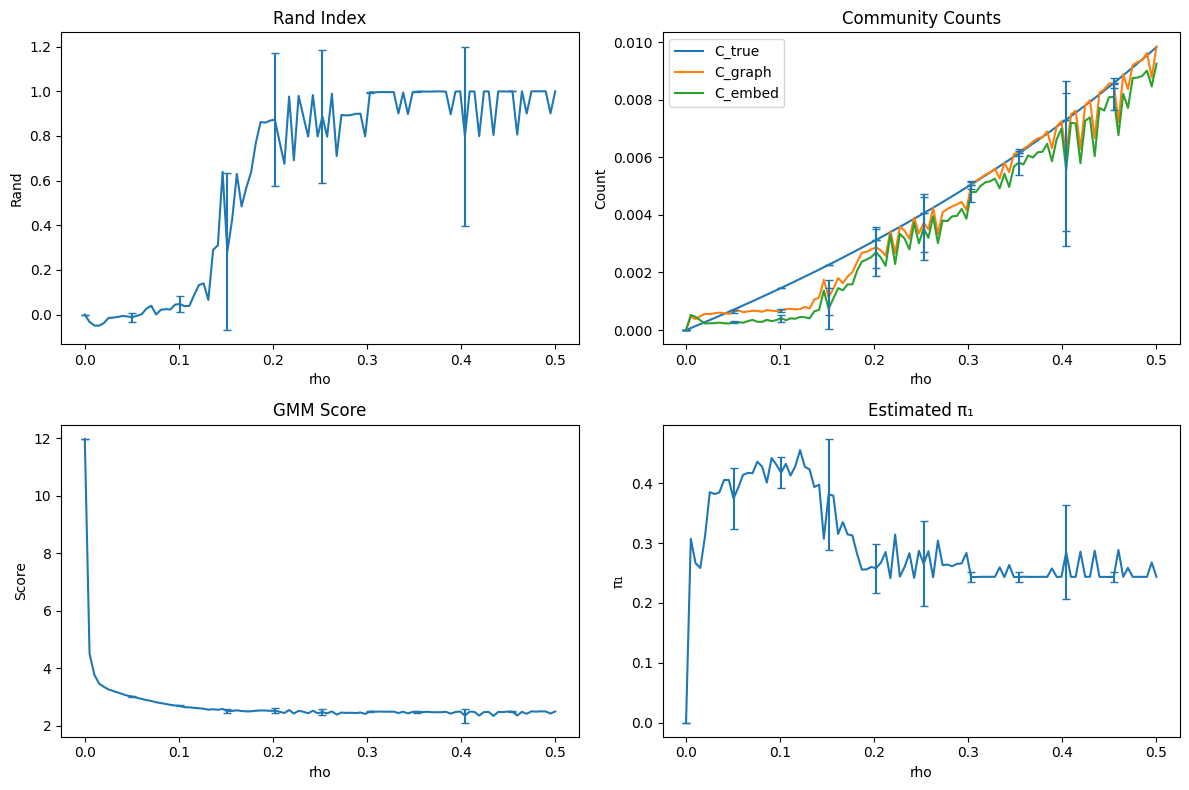

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# metrics_aggregated[m]['mean'] and ['std'] are both arrays of shape (N,)
# rhos is also length N

idxs = np.arange(0, N, N // 10)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1) Rand Index
ax = axes[0, 0]
mean = metrics_aggregated['Rand']['mean']
std  = metrics_aggregated['Rand']['std']
ax.plot(rhos, mean)
ax.errorbar(rhos[idxs], mean[idxs], yerr=std[idxs], fmt='none', capsize=3)
ax.set_title('Rand Index')
ax.set_xlabel('rho')
ax.set_ylabel('Rand')

# 2) Community Counts
ax = axes[0, 1]
for key in ['C_true', 'C_graph', 'C_embed']:
    mean = metrics_aggregated[key]['mean']
    std  = metrics_aggregated[key]['std']
    ax.plot(rhos, mean, label=key)
    ax.errorbar(rhos[idxs], mean[idxs], yerr=std[idxs], fmt='none', capsize=3)
ax.set_title('Community Counts')
ax.set_xlabel('rho')
ax.set_ylabel('Count')
ax.legend()

# 3) GMM Score
ax = axes[1, 0]
mean = metrics_aggregated['GMM_score']['mean']
std  = metrics_aggregated['GMM_score']['std']
ax.plot(rhos, mean)
ax.errorbar(rhos[idxs], mean[idxs], yerr=std[idxs], fmt='none', capsize=3)
ax.set_title('GMM Score')
ax.set_xlabel('rho')
ax.set_ylabel('Score')

# 4) π₁ Estimate
ax = axes[1, 1]
mean = metrics_aggregated['pi_1']['mean']
std  = metrics_aggregated['pi_1']['std']
ax.plot(rhos, mean)
ax.errorbar(rhos[idxs], mean[idxs], yerr=std[idxs], fmt='none', capsize=3)
ax.set_title('Estimated π₁')
ax.set_xlabel('rho')
ax.set_ylabel('π₁')

plt.tight_layout()
plt.show()


C:\Users\Nicol\AppData\Local\Temp\ipykernel_8136\2201965540.py:32: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string " " (-> linestyle=' '). The keyword argument will take precedence.
  ax.plot([], [], ' ', label=stat, linestyle = None, marker = "")


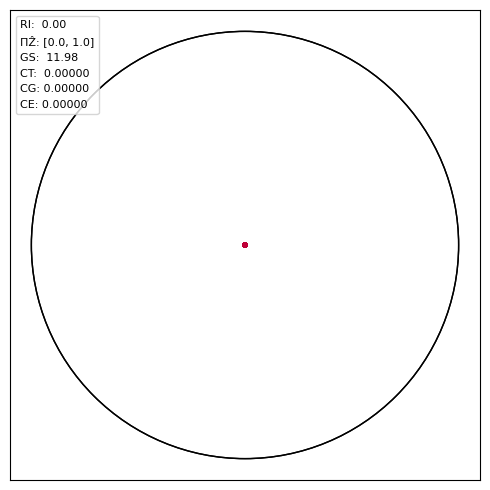

In [ ]:
G = metrics[0]
Z, X, Z_hat, M, Σ, C_true, C_graph, C_embedding, RAND = G.Z, G.X, G.Z_hat, G.M, G.Σ, G.C_true, G.C_graph, G.C_embedding, G.RAND
#Z_hat = label_permutation(Z, Z_hat)
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(X[:, 0], X[:, 1], c=Z, cmap='bwr', marker='.', alpha=0.2)

ax.set_xticks([])
ax.set_yticks([])

for mean, cov in zip(M, Σ):
	eigenvalues, eigenvectors = np.linalg.eigh(cov)
	angle = np.degrees(np.arctan2(eigenvectors[0, 1], eigenvectors[0, 0]))
	width, height = 2 * np.sqrt(6 * eigenvalues)
	ellip = plt.matplotlib.patches.Ellipse(
		mean, width, height, angle=angle, edgecolor='k', facecolor='none', linestyle='solid'
	)
	ax.add_patch(ellip)
Π_hat = list(np.sort(np.diag(G.Π_hat)).round(2))
stats = [f"RI:  {RAND:.2f}",
			f"ΠẐ: {Π_hat}",
			f"GS:  {G.GMM_score:.2f}",
			f"CT:  {C_true:.5f}",
			f"CG: {C_graph:.5f}",
			f"CE: {C_embedding:.5f}"]
for stat in stats:
	ax.plot([], [], ' ', label=stat, linestyle = None, marker = "")
ax.legend(
	loc="upper left",
	fontsize=8,
	handlelength=0,
	handletextpad=0,
)
plt.tight_layout()
plt.show()